# current ds - center is N

In [1]:
# imorts

# imports

# ml
import torch
import torch.nn as nn
from torchvision.models import vgg16
import torch.optim.lr_scheduler as lr_scheduler
import torch.optim as optim
from torchvision.models import vgg16
from torch.utils.data import DataLoader
#from torch.Utils.data import DataLoader
import torch.nn.functional as F

from sklearn.model_selection import train_test_split

# general maths and image manipulation
import numpy as np
import cv2

# general other
from datetime import date
from tqdm import tqdm
import pprint
import collections
from IPython.display import clear_output
import time
import random


# saving in file types
import csv
import json
import pickle
import os

# simulation logger
import wandb

# my functions
import sys
sys.path.append('../../.')
from functions import  ImageProcessor
from dataPreProcessingP3Direction import get_data
from dataloaderP3Direction import IDSWDataSetLoader3
from fns4wandb import set_lossfn
from architectures import eightnnet, PrintLayer
from loopsP3Direction import loop_batch, test_loop_batch, train_val_batch
from plotting import learning_curve, accuracy_curve
from plottingP3Direction import plot_confusion
from modelCardsP3Direction import Cards, get_lin_lay, return_card
from modelManagment import choose_model,choose_scheduler

from fileManagment import save2csv_nest_dict, check_obj4np, save2josn_nested_dict, save2csv, save2json,read_in_json


/its/home/nn268/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/its/home/nn268/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
# directories 

save_location  = "/its/home/nn268/antvis/antvis/optics/res_big_loop_saves/models/p3/testing/" # "/its/home/nn268/antvis/antvis/optics/res_big_loop_saves//models/p3/DIRECTIONLEARNING/"

data_path = "/its/home/nn268/antvis/antvis/optics/NC_IDSW/"

gitHASH = "90f15ed22519ea9a8a5f3b362f52b8b3c23c623c"

model_name = '4c3l'

epochs = 300

tv = [452, 144]

projectNAME = f"RealThing_{model_name}_300E_1e-4_ADAM_Eighths_{tv}"#f"LargeModels_ALLLOCS_{model_name}_{tv}_{epochs}E_1e-4_FixedPeakDistERR" #"test"#

full_path = save_location+projectNAME+"/"+model_name+"/"
if not os.path.exists(full_path):
    os.makedirs(full_path)

save_location = full_path

In [3]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"

In [4]:
len(os.listdir(data_path)) # 2744

2745

In [5]:
# wandb log

wandb.login()

wandb: WARNING The anonymous setting has no effect and will be removed in a future version.
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /its/home/nn268/.netrc.
wandb: Currently logged in as: naughticalnonsence (antvis) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
# get current datetime


In [7]:
# import model cards
cards = Cards()
#print(cards.modelcards)
modelcards = cards.modelcards

if model_name != 'resnet18':
    modelcard = return_card(modelcards, key='name', targetValue=model_name)
    print(modelcard)
resolutioncards = cards.resolutioncards
resolutioncard = return_card(resolutioncards, key='resolution', targetValue=tv)



[{'name': '4c3l', 'model': '4c3l', 'channels': 3, 'Ks': (3, 5), 'f_lin_lay': [530432, 133760, 34560, 9984, 2304, 512, 256], 'idx': 4, 'dropout': 0.2}]




modelcard[0]['f_lin_lay'][0] = 1032192    ## Just for testing an individual model - Remove and make new modelcards3PDirections file in real.

print(modelcard)
print(resolutioncard)

In [8]:
# create config dict - add cards and parameters

learning_rate =  1e-4


seeds = [42, 7, 56, 23, 22, 69]


batchsize = 64#, 64]


half_ciprange = 22 # (roughly half of 45)
std_dev = 7



loss_fn = ['MSE']
optim = ["adam"]

scheduler_value = "NoSched"

config = dict({'name': f"Sweep on {model_name} at {resolutioncard[0]['resolution']}_clip:{half_ciprange}"}) #config = dict({'name': 'Sweep on 2C'})


config.update({"method": "bayes", "metric":{"goal": "minimize", "name": "t_loss"},
              "parameters": {"epochs" :{"value" : epochs},
                             "batch_size": {"value": batchsize},
                             "learning_rate":{"value": learning_rate},
                             "loss_fn_cards": {"value":loss_fn},
                             "optimiser": {"value": optim},
                             "seeds": {"values": seeds},
                              "half_ciprange": {"value":half_ciprange},
                             "std_dev":{"value":std_dev},
                             'model_cards':{"value":modelcard},
                             'resolution_cards':{"value":resolutioncard}
                            }})


In [9]:
def getAcc_fromdict(listdict):
    baseacc = []
    MSE = []
    MAE = []
    peak = []
    for item in listdict:
        baseacc.append(item['baseAcc'])
        MSE.append(item['MSE'])
        MAE.append(item['MAE'])
        peak.append(item['peakDist'])
    return baseacc, MSE, MAE, peak

In [10]:

def _go(config=None):
    
    if len(gitHASH) <1:
        print("YOU FORGET THE GIT HASH")
        return
    else:
        #print('Git Hash registered')
        pass
    d = date.today()
    mc = modelcard[0]
    with wandb.init(config=config):  
        config = wandb.config

        for model_idx, model_card in enumerate(modelcard): #(config['model_cards']):
            start = time.process_time()
            print(model_card)
            model_name = model_card['model']
            model_index = model_card['idx']
            dropout = model_card['dropout'] 
            
            output_lin_lay = 360 ###### Output labels for direction prediction specifically. 
            
            
            for res_idx, resolution_card in enumerate(resolutioncard):
                resolution = resolution_card['resolution']
                lin_lay = get_lin_lay(model_card, resolution)
            
                seed = config.seeds
                loss = config.loss_fn_cards
                torch.cuda.empty_cache()

                batch = config.batch_size 

                print('Model: ', str(model_name), f" idx: {model_idx} / {len(config.model_cards)}")
                print('resolution: ', str(resolution), f" idx: {res_idx} / {len(config['resolution_cards'])}")
                print('seed: ', str(seed))
                print('loss function: ', str(loss))
                print('Batch size: ', config.batch_size)
                print('Training epochs: ', config.epochs)
                run_start_time = time.process_time()
                print('start time: ',run_start_time)

                epochs = config['epochs'] #40

                IP = ImageProcessor(device)

                wandb.log({'gitHash':gitHASH})
                wandb.log({'Epochs': epochs})
                wandb.log({'schedType':scheduler_value})

                save_dict = {'Run' : f"{model_name}_{resolution}_{d}",
                             'start_epoch' : 0,
                             'Current_Epoch': 0,
                             'save_location' : save_location,
                            'scheduler': scheduler_value}

                if model_name == 'resnet18':
                    model = resnet18(weights=None, num_classes =360).to(device)
                    model_index = 100
                else:
                    lin_lay = get_lin_lay(model_card, resolution)
                    dropout = model_card['dropout'] 
                    print(f"Model Name {model_name}")
                    model = choose_model(model_name, lin_lay, dropout, output_lin_lay).to(device)

                half_ciprange = config.half_ciprange
                std_dev = config.std_dev

                x_train, y_train, x_val, y_val, x_test, y_test = get_data(seed, "/its/home/nn268/antvis/antvis/optics/NC_IDSW/")
                av_lum = IP.new_luminance(x_train)
                train = (x_train, resolution, av_lum, model_name, config.half_ciprange, config.std_dev, batch)
              
                # FOR increases DS size in training via augmentations (yaw augmentations) only create the DSL for test here, Train and Val in epoch loop
                # that will give different yaw augmentations each loop
                # if i also increase epochs, I get more unique tries for direction learning
                
                test_ds= IDSWDataSetLoader3(x_test, resolution,av_lum,model_name, config.half_ciprange, config.std_dev, device)
                test = DataLoader(test_ds, batch_size=config.batch_size, shuffle=True, drop_last=True) #, num_workers=2
    
                print(f"len training : {len(x_train)}     len val : {len(x_val)}    len test : {len(x_test)}")

                loss_fn = set_lossfn(loss)
                
                # set optimizer
                optimizer = torch.optim.Adam(model.parameters(),lr=config.learning_rate)
                scheduler = choose_scheduler(save_dict, optimizer)

                wandb.watch(model, loss_fn, log='all', log_freq=2, idx = model_index)

                loop_run_name = f"{save_dict['Run']}_{resolution}_{config.learning_rate}_{scheduler_value}_{seed}_{loss}"
                model, save_dict = train_val_batch(model, train, x_val, save_dict, config.learning_rate, loss_fn,epochs, config.batch_size, optimizer, scheduler_value, device, config)

                test_acc, test_predict_list, y_test = test_loop_batch(model,test, loss_fn, config.batch_size, device,config, runname=loop_run_name, save_loc = save_dict['save_location']) #model, model_name, X, Y, res, pad, loss_fn, device, num_classes=11
                test_predict_numerical = [p.item() for p in test_predict_list]
                y_test_numerical = [y.item() for y in y_test]
                print(np.unique(test_predict_list))
                
                print(' \n train Acc: ', save_dict['t_accuracy_list'][-1])
                print(' \n val Acc: ', save_dict['v_accuracy_list'][-1])
                print(' \n test Acc: ', test_acc)
                
                save_dict.update({'test_acc': test_acc})
                save_dict.update({'test_predict': test_predict_list})
                save_dict.update({'test_labels': list(y_test)})

                t_acc = save_dict['t_accuracy_list']
                tbase_acc, tMSE, tMAE, t_peakdist = getAcc_fromdict(t_acc)
                
                v_acc = save_dict['v_accuracy_list']
                vbase_acc, vMSE, vMAE, v_peakdist = getAcc_fromdict(v_acc)

                learning_curve(save_dict['t_loss_list'], save_dict['v_loss_list'], save_location=save_dict['save_location'],run_name=loop_run_name)
                
                accuracy_curve(tbase_acc, vbase_acc ,save_location=save_dict['save_location'],run_name="Basic"+loop_run_name)
                accuracy_curve(tMSE, vMSE ,save_location=save_dict['save_location'],run_name="MSE"+loop_run_name)
                accuracy_curve(tMAE, vMAE ,save_location=save_dict['save_location'],run_name="MAE"+loop_run_name)
                accuracy_curve(t_peakdist, v_peakdist ,save_location=save_dict['save_location'],run_name="PeakDist"+loop_run_name)
                
                print(f"test_predict_numerical :   {test_predict_numerical}")
                print(f"y_test_numerical :     {y_test_numerical}")
                plot_confusion(predictions= test_predict_numerical, actual= y_test_numerical, title = "Test Confusion matrix", run_name = loop_run_name,save_location =save_dict['save_location'])
                
                
                wandb.log({'test_predict': test_predict_list})
                wandb.log({'test_labels': list(y_test)})
                #saving
                diction = {}
                d = date.today()
                d=str(d)
                diction.update({'Date':d})
                diction.update({'gitHASH':str(gitHASH)})
                diction.update({'model_name': str(model_name)})
                diction.update({'loss_fn': str(loss)})
                diction.update({'lr': str(config.learning_rate)})
                diction.update({'seed': str(seed)})
                diction.update({'resolution': str(resolution)})
                diction.update({'lin_lay': int(lin_lay)})
                diction.update({'run time': (time.process_time() - run_start_time)})
                diction.update(save_dict)
                
                _save_location = save_dict['save_location']
                title = save_dict['Run']
                save2json(diction, loop_run_name, _save_location)
                save2csv(diction, title, _save_location)

                diction['model.state_dict'] = model.state_dict() #to('cpu').

                with open(f"{save_location}{loop_run_name}.pkl", 'wb+') as f:
                    pickle.dump(diction, f)
                                
                print(f' \n END {model_name} {resolution} Run Time: ',time.process_time() - run_start_time)
                torch.cuda.empty_cache()


Create sweep with ID: lv7p96jo
Sweep URL: https://wandb.ai/antvis/RealThing_4c3l_300E_1e-4_ADAM_Eighths_%5B452%2C%20144%5D/sweeps/lv7p96jo


wandb: Agent Starting Run: l69lfthc with config:
wandb: 	batch_size: 64
wandb: 	epochs: 300
wandb: 	half_ciprange: 22
wandb: 	learning_rate: 0.0001
wandb: 	loss_fn_cards: ['MSE']
wandb: 	model_cards: [{'Ks': [3, 5], 'channels': 3, 'dropout': 0.2, 'f_lin_lay': [530432, 133760, 34560, 9984, 2304, 512, 256], 'idx': 4, 'model': '4c3l', 'name': '4c3l'}]
wandb: 	optimiser: ['adam']
wandb: 	resolution_cards: [{'index': 0, 'padding': 5, 'resolution': [452, 144]}]
wandb: 	seeds: 23
wandb: 	std_dev: 7
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /its/home/nn268/.netrc.


{'name': '4c3l', 'model': '4c3l', 'channels': 3, 'Ks': (3, 5), 'f_lin_lay': [530432, 133760, 34560, 9984, 2304, 512, 256], 'idx': 4, 'dropout': 0.2}
Model:  4c3l  idx: 0 / 1
resolution:  [452, 144]  idx: 0 / 1
seed:  23
loss function:  ['MSE']
Batch size:  64
Training epochs:  300
start time:  12.933371529
Model Name 4c3l
/its/home/nn268/antvis/antvis/optics/NC_IDSW/
len training : 1344     len val : 576    len test : 824
set_lossfn    lf  ['MSE']


  0%|                               | 0/300 [00:00<?, ?it/s]

Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


...

peak dist means  73.57291666666667
v loss  0.30834078416228294
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  77.36755952380952
tacc:  {'baseAcc': 20.3125, 'MSE': 0.03427055229743322, 'MAE': 0.05059350565785453, 'peakDist': 77.36755952380952}
Validating...


  5%|█                     | 14/300 [01:20<27:08,  5.69s/it]

peak dist means  74.46354166666667
v loss  0.3083019517362118
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  75.65327380952381
tacc:  {'baseAcc': 20.3125, 'MSE': 0.034252644649573734, 'MAE': 0.050545700781402136, 'peakDist': 75.65327380952381}
Validating...


  5%|█                     | 15/300 [01:25<27:03,  5.70s/it]

peak dist means  72.22569444444444
v loss  0.3080068491399288
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  78.34151785714286
tacc:  {'baseAcc': 21.875, 'MSE': 0.03425845184496471, 'MAE': 0.050560295759212406, 'peakDist': 78.34151785714286}
EPOCH    15 / 300:


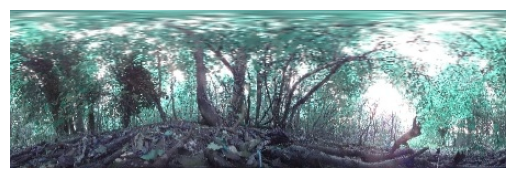

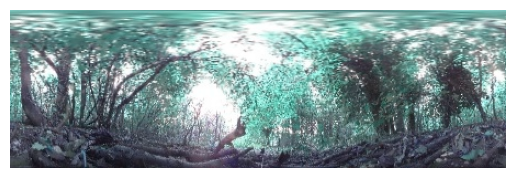

TRUE LABEL    :          62
PREDICTION    :          8
Validating...


  5%|█▏                    | 16/300 [01:31<27:07,  5.73s/it]

peak dist means  75.40625
v loss  0.30805230140686035
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  73.92113095238095
tacc:  {'baseAcc': 23.4375, 'MSE': 0.03425573539875802, 'MAE': 0.050547950147163304, 'peakDist': 73.92113095238095}
Validating...


  6%|█▏                    | 17/300 [01:37<26:53,  5.70s/it]

peak dist means  73.51041666666667
v loss  0.30816931650042534
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  74.39955357142857
tacc:  {'baseAcc': 28.125, 'MSE': 0.0342462243778365, 'MAE': 0.05052522605373746, 'peakDist': 74.39955357142857}
Validating...


...

peak dist means  67.81423611111111
v loss  0.3071782775223255
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  70.79166666666667
tacc:  {'baseAcc': 28.125, 'MSE': 0.034167472805295675, 'MAE': 0.05035504503619103, 'peakDist': 70.79166666666667}
Validating...


 14%|███                   | 42/300 [03:58<24:24,  5.68s/it]

peak dist means  68.08333333333333
v loss  0.3075026907026768
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  72.36830357142857
tacc:  {'baseAcc': 29.6875, 'MSE': 0.0341754403142702, 'MAE': 0.05038204824640637, 'peakDist': 72.36830357142857}
Validating...


 14%|███▏                  | 43/300 [04:04<24:19,  5.68s/it]

peak dist means  71.01215277777777
v loss  0.3076174892485142
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  73.53422619047619
tacc:  {'baseAcc': 26.5625, 'MSE': 0.0342123568767593, 'MAE': 0.050460061679283776, 'peakDist': 73.53422619047619}
EPOCH    43 / 300:


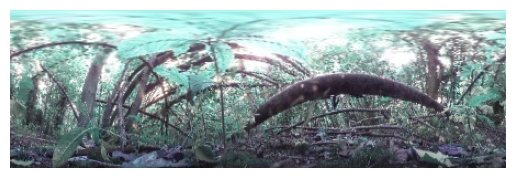

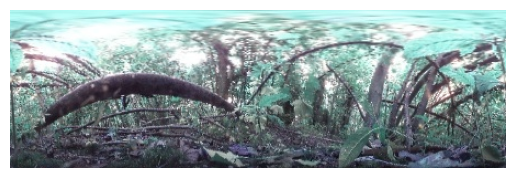

TRUE LABEL    :          332
PREDICTION    :          354
Validating...


 15%|███▏                  | 44/300 [04:10<24:20,  5.70s/it]

peak dist means  74.56770833333333
v loss  0.30768200755119324
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  71.19122023809524
tacc:  {'baseAcc': 39.0625, 'MSE': 0.03416042402386665, 'MAE': 0.050339432344550177, 'peakDist': 71.19122023809524}
Validating...


 15%|███▎                  | 45/300 [04:15<24:14,  5.70s/it]

peak dist means  68.72222222222223
v loss  0.30714141950011253
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  71.09821428571429
tacc:  {'baseAcc': 23.4375, 'MSE': 0.03416953608393669, 'MAE': 0.05036859214305878, 'peakDist': 71.09821428571429}
Validating...


...

100%|████████████████████▉| 299/300 [28:17<00:05,  5.66s/it]

peak dist means  34.953125
v loss  0.2980831451714039
Data Loading...
Training...
Optimizer present:  Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)
peak dist means  20.81547619047619
tacc:  {'baseAcc': 79.6875, 'MSE': 0.03215205882276807, 'MAE': 0.047408870997883025, 'peakDist': 20.81547619047619}
Validating...


100%|█████████████████████| 300/300 [28:22<00:00,  5.68s/it]

peak dist means  34.17534722222222
v loss  0.29783814027905464


5
5
checkSaveName Start
checkSaveName match
checkSaveName while loop starting
checkSaveName while loop end


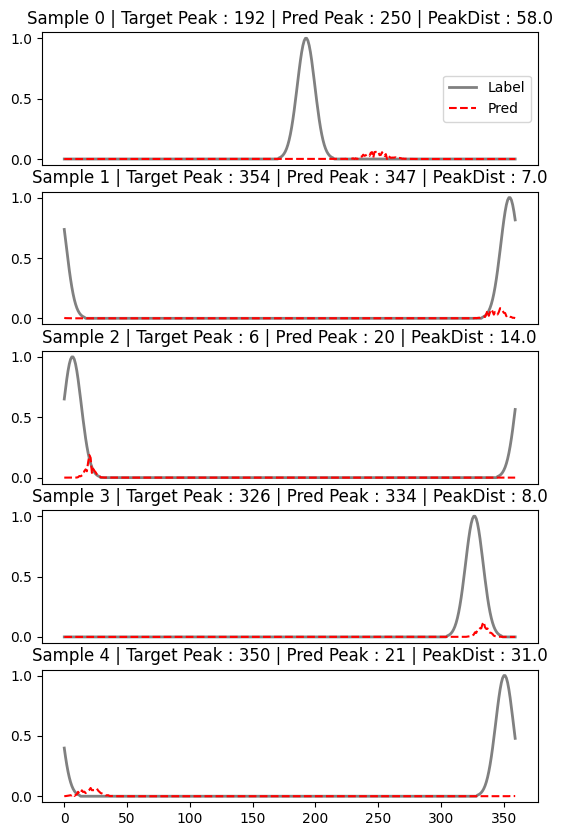

[  0   1   2   3   4   6   7   8  10  11  12  13  14  15  16  17  18  20
  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36  37  38
  40  41  43  45  46  47  49  53  54  55  57  64  66  67  69  70  71  73
  74  76  77  79  83  86  87  88  90  93  94  95  96  97  98 100 102 103
 105 106 107 108 109 111 115 116 118 122 124 127 128 131 135 136 137 140
 142 143 144 145 147 149 151 152 153 156 157 159 160 162 163 165 168 169
 175 177 179 181 182 183 186 187 188 189 191 192 194 197 199 202 203 204
 208 209 210 211 212 213 215 216 218 219 220 221 222 223 230 235 236 238
 239 242 243 245 248 249 250 254 255 256 258 259 261 262 263 265 266 273
 274 275 276 278 279 280 282 283 286 287 290 292 293 294 297 299 305 306
 308 309 311 313 316 317 318 319 320 321 322 323 324 325 326 327 328 329
 331 332 333 334 335 336 338 339 340 341 343 344 346 347 348 349 350 351
 353 354 355 357 358 359]
 
 train Acc:  {'baseAcc': 79.6875, 'MSE': 0.03215205882276807, 'MAE': 0.047408870997883025, 'peak

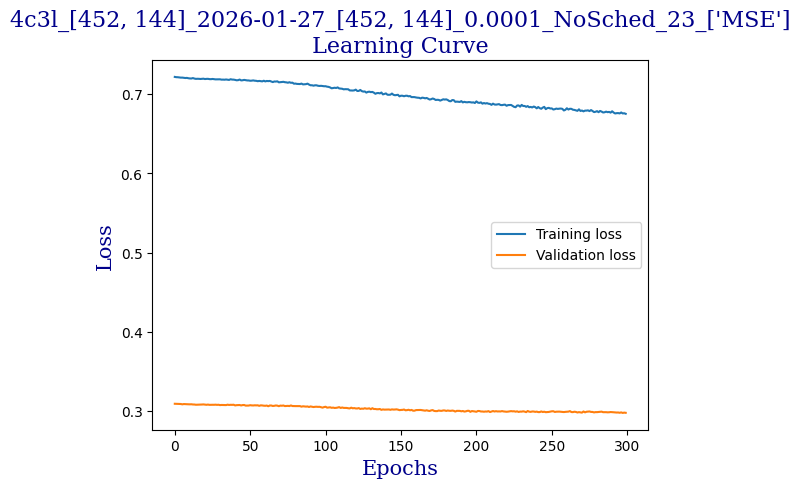

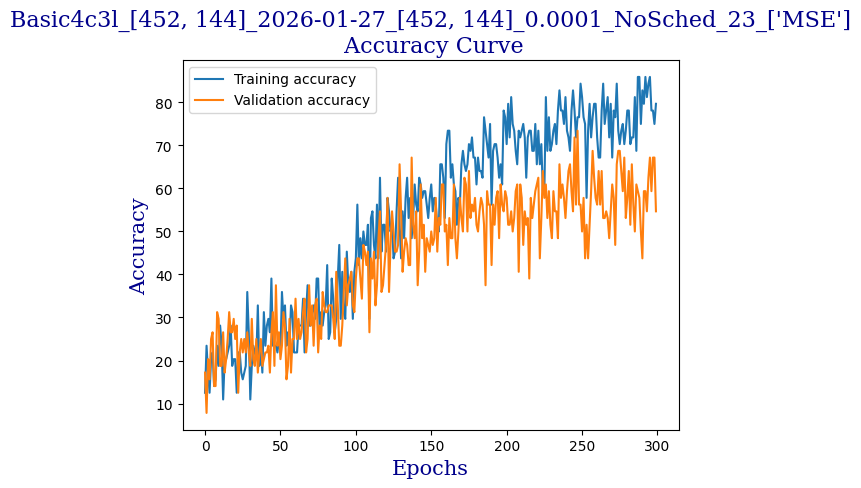

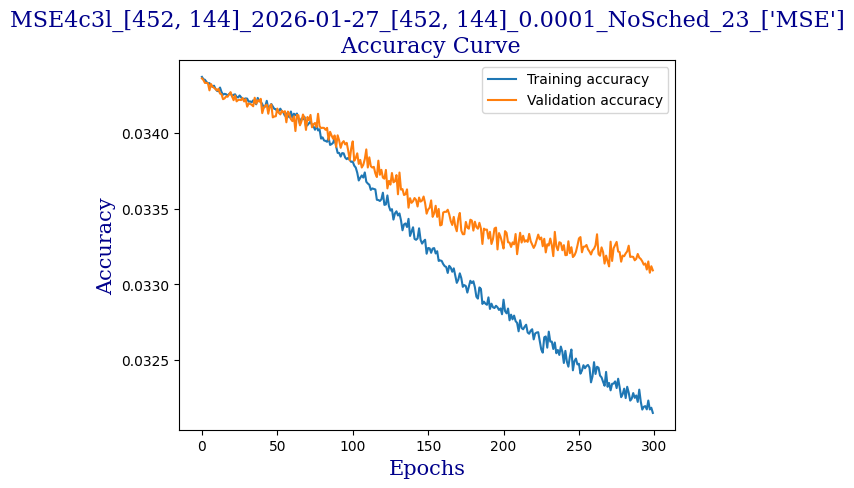

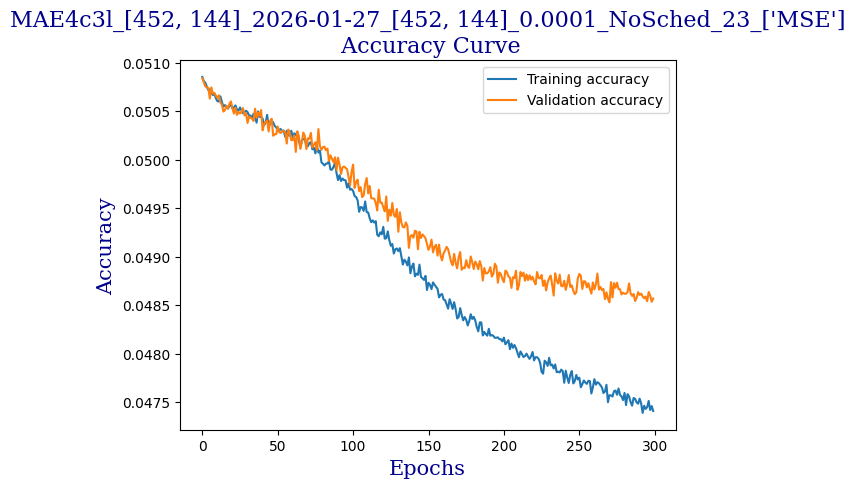

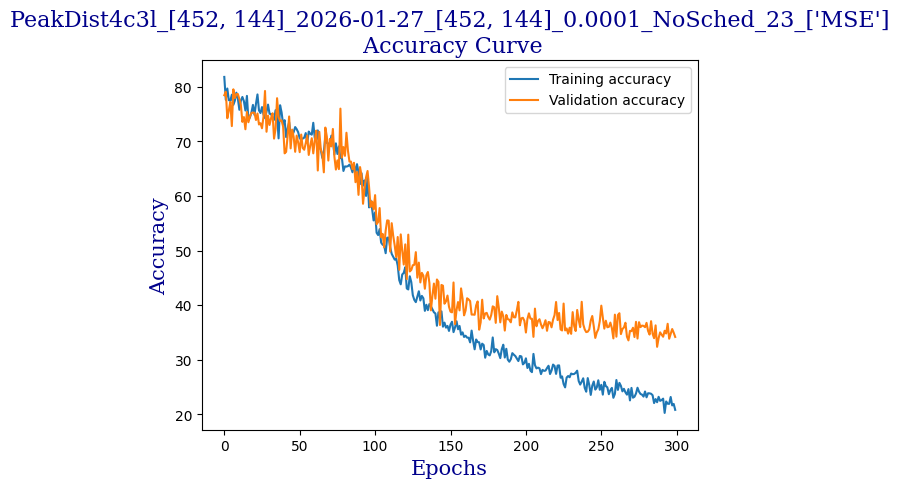

test_predict_numerical :   [223, 37, 349, 238, 15, 26, 6, 13, 348, 187, 21, 230, 105, 328, 306, 102, 349, 354, 83, 12, 194, 324, 349, 230, 0, 20, 203, 186, 142, 347, 259, 324, 93, 20, 76, 266, 351, 222, 320, 199, 238, 6, 343, 33, 324, 344, 151, 265, 6, 25, 109, 33, 261, 22, 118, 331, 179, 55, 218, 250, 286, 27, 179, 326, 136, 280, 336, 194, 182, 40, 346, 55, 7, 263, 36, 354, 189, 54, 11, 318, 219, 37, 122, 107, 100, 297, 194, 0, 325, 106, 349, 90, 230, 73, 143, 7, 335, 8, 23, 128, 327, 13, 357, 118, 122, 34, 354, 328, 320, 8, 308, 111, 238, 32, 28, 108, 20, 311, 183, 69, 313, 40, 37, 343, 242, 256, 165, 149, 335, 15, 168, 202, 215, 219, 325, 292, 294, 319, 323, 156, 73, 329, 6, 250, 1, 194, 263, 21, 24, 329, 55, 45, 93, 21, 25, 266, 249, 12, 332, 332, 341, 103, 157, 131, 28, 16, 55, 6, 0, 144, 339, 11, 355, 159, 37, 204, 327, 20, 0, 33, 355, 6, 136, 265, 12, 189, 258, 323, 67, 334, 30, 333, 35, 12, 79, 334, 266, 199, 37, 86, 73, 6, 265, 358, 349, 323, 318, 165, 235, 305, 93, 136, 210, 

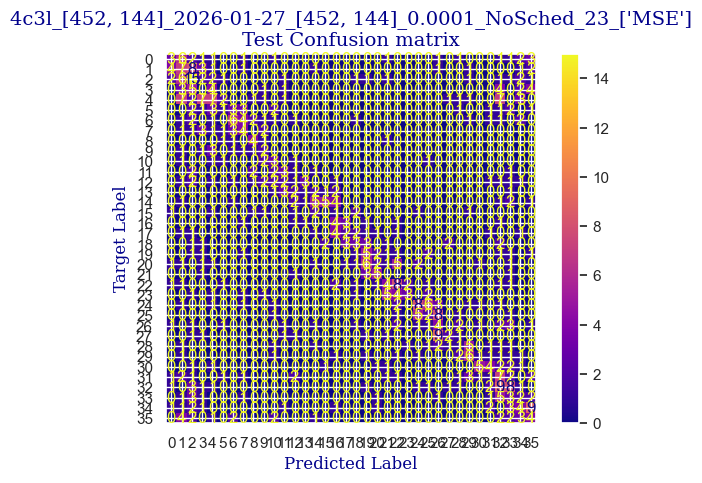

 
 END 4c3l [452, 144] Run Time:  18234.904494226997


Epochs,▁
Test acc rough,▆▁█▅▅▇▅▄▇▅▆▃
TrainAcc rough,▁▂▂▂▁▂▃▃▂▃▃▄▂▃▂▂▄▃▃▄▄▅▅▄▆▆▆▆▇▆▇▆▇▇▇█▇█▇▇
ValAcc rough,▂▁▁▃▃▃▃▄▃▃▆▃▅▄▆▅▄▆▆▆▇▆▅█▇█▆▆▇▇▇▆▇▇▇█▇▆▇▆
c_epoch,▁▁▁▂▂▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▆▆▆▆▆▇▇▇████
t_loss,█████▇▇▇▇▇▇▇▇▆▆▆▅▅▅▅▅▅▄▄▄▃▃▃▃▃▃▃▃▂▂▂▁▁▁▁
test_acc_MAE,▃█▁▄▅▁▃▅▁▄▅▅
test_acc_MSE,▃█▁▃▅▂▃▆▁▄▅▅
test_peakDist,▃█▁▇▁▃▅▅▄▇▅▅
train_err_MAE,████▇▇██▇▇▇▇▇▇▆▆▆▅▅▆▄▅▄▃▂▂▃▂▃▂▂▂▂▂▃▁▃▂▂▂
+6,...


In [ ]:
sweep_id = wandb.sweep(sweep= config, project=projectNAME)

wandb.agent(sweep_id, function=_go, count=20)

In [ ]:
#_go(config)